In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yapss
from yapss import math

problem = yapss.Problem(name="Simple_Cycler", nx=[6], nd = 3)
mu = 1.2150584270572e-2

In [2]:
C_value = 3.151175879508174
W_cf = 1
W_c = 1
W_u = 1
W_v = 1
W_theta = 0.5

theta = math.pi/3
phi = theta/2

In [3]:
def objective(arg):
    xi, yi, zi, vxi, vyi, vzi = arg.phase[0].initial_state
    xf, yf, zf, vxf, vyf, vzf = arg.phase[0].final_state
    c1, c2, c3 = math.cross([vxi, vyi, vzi], [vxf, vyf, vzf])

    r1 = math.sqrt((xf + mu)**2 + yf**2 + zf**2)
    r2 = math.sqrt((xf - 1 + mu)**2 + yf**2 + zf**2)
    U = -0.5*(xf**2 + yf**2) - (1 - mu)/r1 - mu/r2
    Cf = -2*U - (vxf**2 + vyf**2 + vzf**2)

    arg.objective = W_v*(c1**2 + c2**2 + c3**2)

def continuous(arg):
    x, y, z, vx, vy, vz = arg.phase[0].state

    r1 = math.sqrt((x + mu)**2 + y**2 + z**2)
    r2 = math.sqrt((x - 1 + mu)**2 + y**2 + z**2)
    U = -0.5*(x**2 + y**2) - (1 - mu)/r1 - mu/r2
    ax = x - (1 - mu)*(x + mu)/r1**3 - mu*(x - 1 + mu)/r2**3 + 2*vy
    ay = y - (1 - mu)*y/r1**3 - mu*y/r2**3 - 2*vx
    az = -(1 - mu)*z/r1**3 - mu*z/r2**3

    C = -2*U - (vx**2 + vy**2 + vz**2)

    arg.phase[0].dynamics = [vx, vy, vz, ax, ay, az]

def discrete(arg):
    xi, yi, zi, _, _, _ = arg.phase[0].initial_state
    xf, yf, zf, _, _, _ = arg.phase[0].final_state
    arg.discrete = [xf-xi, yf-yi, zf-zi]

In [4]:
problem.functions.objective = objective
problem.functions.continuous = continuous
problem.functions.discrete = discrete

In [5]:
# def y_dot_initial(x, y, z, C):
#     return -math.sqrt(-2*U(x, y, z) - C)

# x_guess = -0.767856324800
# z_guess = 0
# zdot_guess = 0
# initial_guess = np.array([x_guess, 0, z_guess, 0, y_dot_initial(x_guess, 0, z_guess, C_value), zdot_guess])

In [6]:
def day_to_gen(t):
    return t*2*math.pi/27.321661
def gen_to_day(t):
    return t*27.321661/2/math.pi

In [ ]:
guess_sol = np.load("3dorbit.npz")
state_guess = guess_sol["state"]
for i in range (np.size(state_guess, 1)):
    xs, ys, zs, vxs, vys, vzs = state_guess[:,i]
    xsf = xs
    ysf = ys - 2*ys*math.sin(phi)**2
    zsf = 2*ys*math.sin(phi)*math.cos(phi)
    vxsf = vxs
    vysf = vys - 2*vys*math.sin(phi)**2
    vzsf = 2*vys*math.sin(phi)*math.cos(phi)
    state_guess[:,i] = [xsf, ysf, zsf, vxsf, vysf, vzsf]

time_guess = guess_sol["time"]

phase = problem.guess.phase[0]
phase.time = time_guess
phase.state = state_guess

In [8]:
x, y, z, vx, vy, vz = state_guess
np.min(math.atan2(z,y)%math.pi)
np.min(math.atan2(vz,vy)%math.pi)

np.float64(1.0471975511965974)

In [9]:
bounds = problem.bounds.phase[0]
bounds.initial_time.lower = bounds.initial_time.upper = 0
problem.bounds.discrete.lower = problem.bounds.discrete.upper = [0, 0, 0]

In [10]:
problem.derivatives.method = "auto"
problem.derivatives.order = "second"
problem.spectral_method = "lgl"
segments, points = 100, 10
problem.mesh.phase[0].collocation_points = segments*[points]
problem.mesh.phase[0].fraction = segments*[1/segments]

In [11]:
problem.ipopt_options.mu_strategy = "adaptive"
problem.ipopt_options.print_level = 3
problem.ipopt_options.print_user_options = "yes"
problem.ipopt_options.timing_statistics = "yes"
problem.ipopt_options.sb = "yes"
problem.ipopt_options.tol = 1e-8

In [12]:
solution = problem.solve()

In [13]:
state = solution.phase[0].state
time = solution.phase[0].time
control = solution.phase[0].control
time_c = solution.phase[0].time_c
t0 = solution.phase[0].initial_time
tf = solution.phase[0].final_time
x, y, z, vx, vy, vz = state
print("Orbit Period (nondimensional time)", tf)
print("Difference in final x position", x[0] - x[-1])
print("Difference in final y position", y[0] - y[-1])
print("Difference in final z position", z[0] - z[-1])
print("Difference in final x velocity", vx[0] - vx[-1])
print("Difference in final y velocity", vy[0] - vy[-1])
print("Difference in final z velocity", vz[0] - vz[-1])

Orbit Period (nondimensional time) 10.554290899721744
Difference in final x position 0.0
Difference in final y position 0.0
Difference in final z position 0.0
Difference in final x velocity 0.5412324193137129
Difference in final y velocity 0.00022698840602701145
Difference in final z velocity -0.00023500421405163354


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Maximum Z Error 0.00014043918092695984


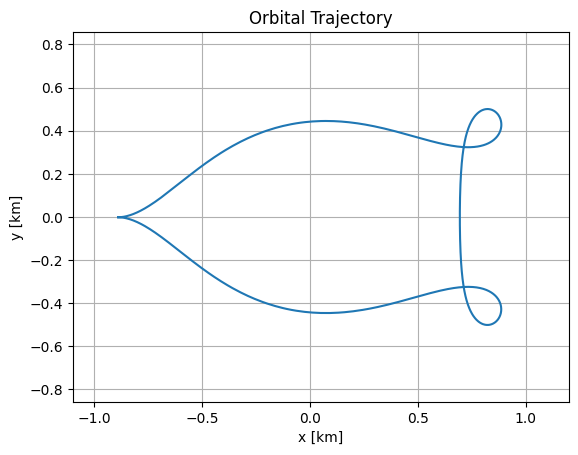

In [14]:
plt.figure()
plt.plot(x, y)
plt.axis("equal")
plt.xlim([-1.1, 1.2])
plt.ylim([-1, 1])
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.title("Orbital Trajectory")
plt.grid(True)
z_err = np.max(np.abs(z)) # Maximum z error
print("Maximum Z Error", z_err)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


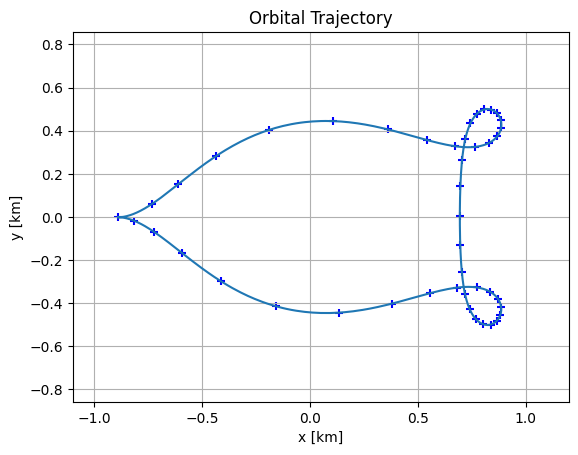

In [15]:
t_tick_days = np.arange(0, 45, 1)
t_tick = day_to_gen(t_tick_days)

from scipy.interpolate import interp1d

fx = interp1d(time, x, kind='cubic', bounds_error=False, fill_value="extrapolate")
fy = interp1d(time, y, kind='cubic', bounds_error=False, fill_value="extrapolate")

x_ticks = fx(t_tick)
y_ticks = fy(t_tick)

plt.figure()
plt.plot(x, y)
plt.axis("equal")
plt.xlim([-1.1, 1.2])
plt.ylim([-1, 1])
plt.xlabel("x [km]")
plt.ylabel("y [km]")
plt.title("Orbital Trajectory")
plt.scatter(x_ticks, y_ticks, marker='+', color='blue')
plt.grid(True)

In [16]:
print("Error [seconds]", abs(gen_to_day(tf) - 44.7538)*24*60*60)       # seconds off from period stated in paper
print("Error [%]", abs(gen_to_day(tf) - 44.7538)/44.7538*100)  # days off expressed as a percent

Error [seconds] 98516.73933420554
Error [%] 2.547806082590399


In [17]:
def U(x, y, z):
    r1 = math.sqrt((x + mu)**2 + y**2 + z**2)
    r2 = math.sqrt((x - 1 + mu)**2 + y**2 + z**2)
    return -0.5*(x**2 + y**2) - (1 - mu)/r1 - mu/r2

In [18]:
C_vals = np.zeros((len(x), 1))
for i in range (len(x)):
    C_vals[i] = -2*U(x[i], y[i], z[i]) - (vx[i]**2 + vy[i]**2 + vz[i]**2)
C_err = np.ptp(C_vals) # Maximum Jacobi constant deviation
print("Maximum Jacobi Constant Deviation", C_err)

Maximum Jacobi Constant Deviation 8.65085780787922e-13


Average Jacobi Constant 2.9822849493818757


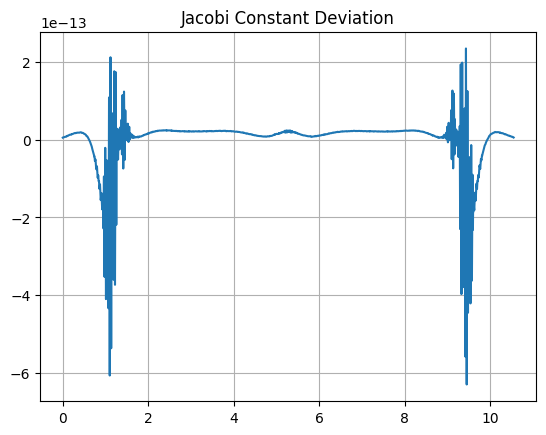

In [19]:
C_mean = np.mean(C_vals)
print("Average Jacobi Constant", C_mean)
plt.figure()
plt.plot(time, (C_vals - C_mean))
plt.title("Jacobi Constant Deviation")
plt.grid(True)

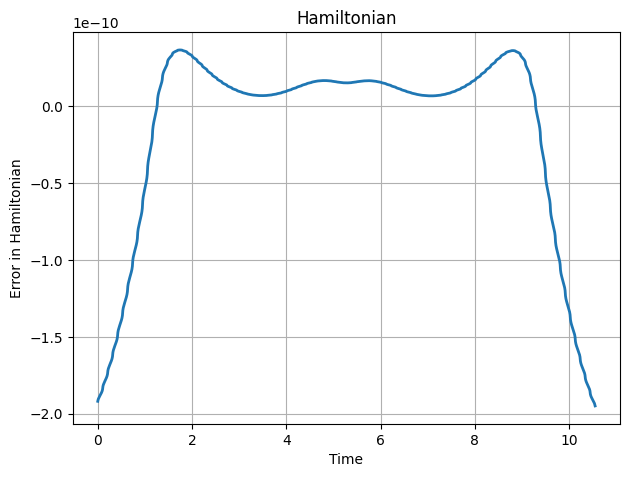

Maximum Hamiltonian Deviation 2.315543208379662e-10


In [20]:
hamiltonian = solution.phase[0].hamiltonian

plt.figure()
plt.plot(time, hamiltonian, linewidth=2)
plt.xlabel("Time")
plt.ylabel(r"Error in Hamiltonian")
plt.tight_layout()
plt.title("Hamiltonian")
plt.autoscale(axis='y')
plt.grid(True)
plt.show()

hamil_dev = np.ptp(hamiltonian)
print("Maximum Hamiltonian Deviation", hamil_dev)

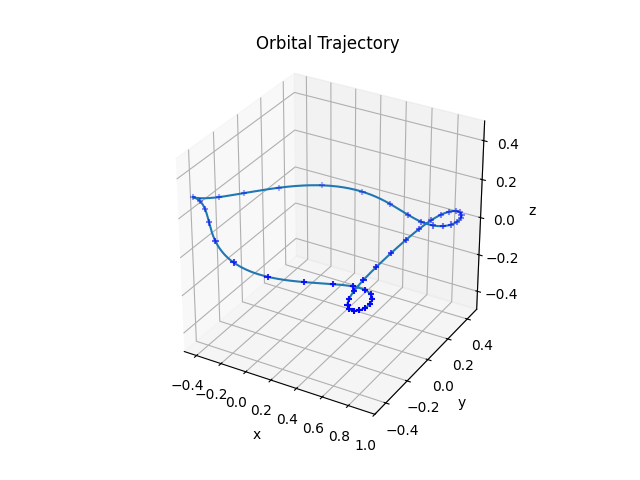

In [22]:
%matplotlib widget

t_tick_days = np.arange(0, 45, 1)
t_tick = day_to_gen(t_tick_days)

from scipy.interpolate import interp1d

fx = interp1d(time, x, kind='cubic', bounds_error=False, fill_value="extrapolate")
fy = interp1d(time, y, kind='cubic', bounds_error=False, fill_value="extrapolate")
fz = interp1d(time, z, kind='cubic', bounds_error=False, fill_value="extrapolate")

x_ticks = fx(t_tick)
y_ticks = fy(t_tick)
z_ticks = fz(t_tick)

fig_3d = plt.figure()
ax = fig_3d.add_subplot(111, projection='3d')
plt.plot(x, y, z)
ax.set_box_aspect([1, 1, 1])
ax.set_xlim([-0.5, 1])
ax.set_ylim([-0.5, 0.5])
ax.set_zlim([-0.5, 0.5])
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.scatter3D(x_ticks, y_ticks, z_ticks, marker='+', color='blue')
plt.title("Orbital Trajectory")
plt.grid(True)